| Name | ID | Department |
| --- | --- | --- |
|Abdelrhman Mohamed Abdelhady Hodib | 2022513643 | Intelligent system|

## Defining the process and cpu scheduler classes

In [19]:
class Process:
    def __init__(self, pid, burst_time, arrival_time):
        self.pid = pid
        self.burst_time = burst_time
        self.remaining_time = burst_time
        self.arrival_time = arrival_time
        self.completion_time = None
        self.waiting_time = None
    
    def execute(self, quantum):
        if self.remaining_time > quantum:
            self.remaining_time -= quantum
            return quantum
        else:
            execution_time = self.remaining_time
            self.remaining_time = 0
            return execution_time

    def complete(self, completion_time):
        self.completion_time = completion_time
        self.waiting_time = self.completion_time - self.burst_time - self.arrival_time

class RoundRobinScheduler:
    def __init__(self, processes, quantum):
        self.processes = processes
        self.quantum = quantum
        self.current_time = 0
    
    def schedule(self):
        ready_queue = self.processes.copy()
        while ready_queue:
            current_process = ready_queue.pop(0)
            execution_time = current_process.execute(self.quantum)
            self.current_time += execution_time
            if current_process.remaining_time > 0:
                ready_queue.append(current_process)
            else:
                current_process.complete(self.current_time)
                print(f"Process {current_process.pid} completed at time {self.current_time}")
        
        total_waiting_time = sum(process.waiting_time for process in self.processes)
        average_waiting_time = total_waiting_time / len(self.processes)
        print(f"Average waiting time: {average_waiting_time}")




## Applying the algorithm 

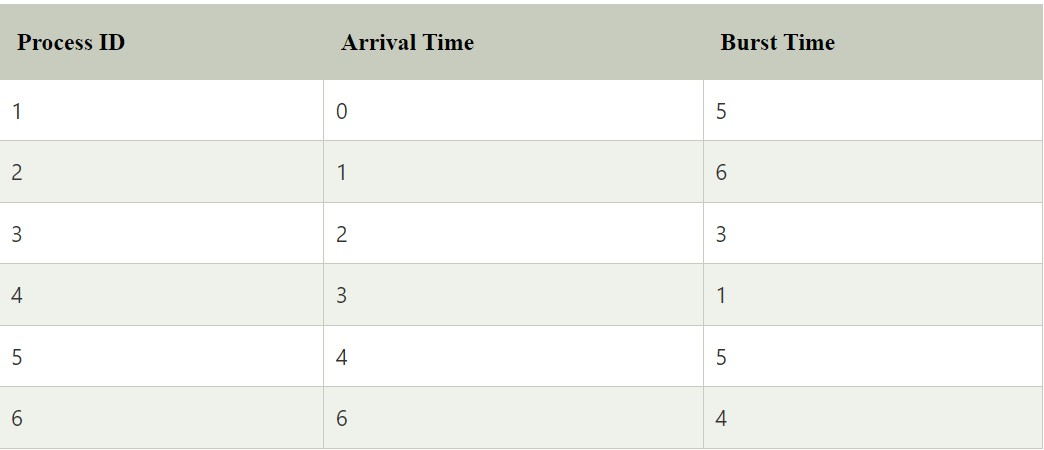

In [20]:
# Create a list of processes with arrival times
processes = [
    Process(1, 5, 0),
    Process(2, 6, 1),
    Process(3, 3, 2),
    Process(4, 1, 3),
    Process(5, 5, 4),
    Process(6, 4, 6),
    
]

# Create a Round Robin scheduler with a quantum of 4
scheduler = RoundRobinScheduler(processes, 4)

# Schedule the processes
scheduler.schedule()

Process 3 completed at time 11
Process 4 completed at time 12
Process 6 completed at time 20
Process 1 completed at time 21
Process 2 completed at time 23
Process 5 completed at time 24
Average waiting time: 11.833333333333334
